<a href="https://colab.research.google.com/github/Amarmurun0212/Diver/blob/main/%D0%A8%D0%91%D0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
Dataset shape: (50000, 15)
Fault label distribution:
 Fault_Label
0    48411
1      732
2      500
3      357
Name: count, dtype: int64
State dim: 15, Action dim: 3
Episode   1/30 | Total Reward:   -70.00 | Avg Loss: 2.37584 | Epsilon: 0.3796
Episode   2/30 | Total Reward:  1350.00 | Avg Loss: 2.54813 | Epsilon: 0.1396
Episode   3/30 | Total Reward:  1961.00 | Avg Loss: 2.43872 | Epsilon: 0.0513
Episode   4/30 | Total Reward:  2303.00 | Avg Loss: 2.45476 | Epsilon: 0.0500
Episode   5/30 | Total Reward:  2296.00 | Avg Loss: 2.31385 | Epsilon: 0.0500
Episode   6/30 | Total Reward:  2365.00 | Avg Loss: 2.64506 | Epsilon: 0.0500
Episode   7/30 | Total Reward:  2234.00 | Avg Loss: 2.44716 | Epsilon: 0.0500
Episode   8/30 | Total Reward:  2266.00 | Avg Loss: 2.56181 | Epsilon: 0.0500
Episode   9/30 | Total Reward:  2218.00 | Avg Loss: 2.68179 | Epsilon: 0.0500
Episode  10/30 | Total Reward:  2390.00 | Avg Loss: 2.59987 | Epsilon: 0.0500
Episode  11/30 | Total Reward:  2048.00 | A

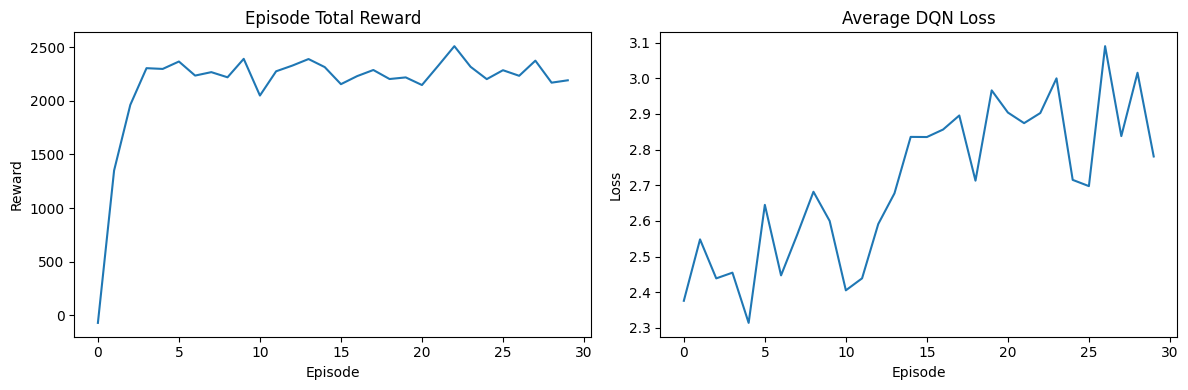


=== Evaluation (5000 steps) ===
Overall decision accuracy : 99.14%
Total fault samples seen  : 155
Faults correctly SHUTDOWN : 142 (91.61%)

Модель хадгалагдлаа: shbm_motor_dqn_policy.pth


In [1]:
# =============================================================================
# SHBM 6kV Motor Digital Twin — Reinforcement Learning (DQN) Self-Learning Agent
# Google Colab-д шууд хуулж ажиллуулах боломжтой бүрэн код
# =============================================================================
#
# Зорилго:
#   - "SHBM_6kV_Motor_DigitalTwin_Dataset.xlsx" датаг ашиглан моторын дижитал
#     орчныг (environment) симуляцлах.
#   - Agent нь сенсорын дата (Custom Gym Environment) ажиглаж, дараах
#     action-уудаас сонголт хийнэ:
#         0 = NORMAL    (хэвийн ажиллагаа)
#         1 = WARNING   (анхааруулга, ачааллыг бууруулах)
#         2 = SHUTDOWN  (моторыг зогсоох - эвдрэл/гэмтлээс хамгаалах)
#   - DQN (Deep Q-Network) ашиглан "self-play"-тэй адил байнгын
#     online сурах (replay buffer + target network update) механизмтай.
#
# ШААРДЛАГАТАЙ FILE:
#   "SHBM_6kV_Motor_DigitalTwin_Dataset.xlsx" -ийг Colab-ийн зүүн талын
#   Files хэсэгт upload хийнэ, эсвэл Google Drive mount хийж замыг тохируулна.
# =============================================================================

# -----------------------------------------------------------------------
# 0. Сангуудыг суулгах (Colab дээр ажиллана)
# -----------------------------------------------------------------------
!pip install gymnasium openpyxl --quiet

# -----------------------------------------------------------------------
# 1. Импорт
# -----------------------------------------------------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import gymnasium as gym
from gymnasium import spaces

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------------------------------------------------
# 2. Дата унших
# -----------------------------------------------------------------------
# Colab дээр файлаа upload хийсний дараа:
DATA_PATH = "SHBM_6kV_Motor_DigitalTwin_Dataset.xlsx"

df = pd.read_excel(DATA_PATH)
df = df.sort_values("Timestamp").reset_index(drop=True)

FEATURE_COLS = [
    "Motor_Load_%", "Stator_Current_A", "Voltage_kV", "Power_kW",
    "Power_Factor", "Speed_RPM", "Bearing_DE_Temp_C", "Bearing_NDE_Temp_C",
    "Winding_Temp_C", "Vibration_mm_s", "Oil_Temp_C", "Ambient_Temp_C",
    "Coal_Feed_tph", "Mill_Diff_Pressure_kPa", "Air_Flow_tph"
]
LABEL_COL = "Fault_Label"

# Normalize features (0-1)
feat_min = df[FEATURE_COLS].min()
feat_max = df[FEATURE_COLS].max()
df_norm = (df[FEATURE_COLS] - feat_min) / (feat_max - feat_min + 1e-9)

DATA = df_norm.values.astype(np.float32)
LABELS = df[LABEL_COL].values.astype(np.int64)

print("Dataset shape:", DATA.shape)
print("Fault label distribution:\n", df[LABEL_COL].value_counts())

# -----------------------------------------------------------------------
# 3. Custom Gym Environment - Motor Digital Twin
# -----------------------------------------------------------------------
class MotorDigitalTwinEnv(gym.Env):
    """
    Сенсорын дата дамжуулагч моторын дижитал орчин.
    Agent нь алхам бүрд дараагийн сенсорын дата (state) ажиглана,
    мотор хэвийн (Fault_Label=0) эсвэл эвдрэлийн төлөвт (1,2,3) орсныг
    харгалзан action сонгоно.

    Action space:
        0 = NORMAL    - хэвийн горимоор ажиллуулна
        1 = WARNING   - анхааруулга, ачаалал бууруулах горим
        2 = SHUTDOWN  - моторыг бүрэн зогсоох

    Reward логик:
        - Хэвийн төлөв (label=0) дээр NORMAL сонговол  -> +1
        - Хэвийн төлөв дээр WARNING/SHUTDOWN сонговол  -> -2 (хэт хэтрүүлсэн)
        - Эвдрэлийн төлөв (label!=0) дээр SHUTDOWN     -> +10 (зөв таамаглал, гэмтлээс сэргийлсэн)
        - Эвдрэлийн төлөв дээр WARNING                 -> +3  (хэсэгчилсэн зөв)
        - Эвдрэлийн төлөв дээр NORMAL                  -> -10 (аюултай, эвдрэл алгассан)
    """
    metadata = {"render_modes": []}

    def __init__(self, data, labels, window_size=1):
        super().__init__()
        self.data = data
        self.labels = labels
        self.n_samples = len(data)
        self.n_features = data.shape[1]
        self.window_size = window_size

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0,
            shape=(self.n_features * window_size,),
            dtype=np.float32
        )
        self.current_idx = 0

    def _get_obs(self):
        start = max(0, self.current_idx - self.window_size + 1)
        window = self.data[start:self.current_idx + 1]
        if len(window) < self.window_size:
            pad = np.repeat(window[0:1], self.window_size - len(window), axis=0)
            window = np.concatenate([pad, window], axis=0)
        return window.flatten().astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Эхлэх цэгийг санамсаргүй сонгоно (continual / episodic learning)
        self.current_idx = np.random.randint(0, self.n_samples - 1)
        return self._get_obs(), {}

    def step(self, action):
        label = self.labels[self.current_idx]

        if label == 0:  # Хэвийн төлөв
            if action == 0:
                reward = 1.0
            elif action == 1:
                reward = -1.0
            else:  # SHUTDOWN
                reward = -2.0
        else:  # Аливаа эвдрэлийн төлөв (1,2,3)
            if action == 2:
                reward = 10.0
            elif action == 1:
                reward = 3.0
            else:  # NORMAL - эвдрэлийг танихгүй, маш аюултай
                reward = -10.0

        self.current_idx += 1
        terminated = self.current_idx >= self.n_samples - 1
        truncated = False

        if not terminated:
            obs = self._get_obs()
        else:
            obs = self._get_obs()

        info = {"true_label": int(label)}
        return obs, reward, terminated, truncated, info


# -----------------------------------------------------------------------
# 4. DQN сүлжээ
# -----------------------------------------------------------------------
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)


# -----------------------------------------------------------------------
# 5. Replay Buffer
# -----------------------------------------------------------------------
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.int64, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


# -----------------------------------------------------------------------
# 6. DQN Agent (Self-learning / continual online learning)
# -----------------------------------------------------------------------
class DQNAgent:
    def __init__(self, state_dim, action_dim,
                 lr=1e-3, gamma=0.99,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.9995,
                 buffer_size=50000, batch_size=64,
                 target_update_freq=500):

        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.step_count = 0

        self.policy_net = DQN(state_dim, action_dim).to(device)
        self.target_net = DQN(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state, explore=True):
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = self.policy_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def store(self, *args):
        self.buffer.push(*args)

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * next_q_values * (1 - dones)

        loss = self.loss_fn(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        # Epsilon decay - тогтмол сурахын хирээр эксплорацийг багасгана
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

        return loss.item()


# -----------------------------------------------------------------------
# 7. Орчин болон Agent-ийг үүсгэх
# -----------------------------------------------------------------------
WINDOW_SIZE = 1
env = MotorDigitalTwinEnv(DATA, LABELS, window_size=WINDOW_SIZE)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim)

print(f"State dim: {state_dim}, Action dim: {action_dim}")

# -----------------------------------------------------------------------
# 8. Сургалтын мөчлөг (Continual / Self-learning loop)
# -----------------------------------------------------------------------
NUM_EPISODES = 30          # 1 episode = датасетийн нэг тойргийн дундах хэсэг
STEPS_PER_EPISODE = 2000   # episode тутамд хийх алхамын тоо

episode_rewards = []
episode_losses = []

for ep in range(1, NUM_EPISODES + 1):
    state, _ = env.reset()
    total_reward = 0
    losses = []

    for t in range(STEPS_PER_EPISODE):
        action = agent.select_action(state, explore=True)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.store(state, action, reward, next_state, float(done))
        loss = agent.update()
        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

        if done:
            state, _ = env.reset()

    avg_loss = np.mean(losses) if losses else 0.0
    episode_rewards.append(total_reward)
    episode_losses.append(avg_loss)

    print(f"Episode {ep:3d}/{NUM_EPISODES} | "
          f"Total Reward: {total_reward:8.2f} | "
          f"Avg Loss: {avg_loss:.5f} | "
          f"Epsilon: {agent.epsilon:.4f}")

# -----------------------------------------------------------------------
# 9. Сургалтын үр дүнг харуулах (graph)
# -----------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(episode_rewards)
axes[0].set_title("Episode Total Reward")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")

axes[1].plot(episode_losses)
axes[1].set_title("Average DQN Loss")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------
# 10. Сургасан agent-ийг датасет дээр evaluate хийх
# -----------------------------------------------------------------------
def evaluate_agent(agent, env, n_steps=5000):
    state, _ = env.reset()
    correct = 0
    shutdown_caught = 0
    total_faults = 0

    for _ in range(n_steps):
        action = agent.select_action(state, explore=False)
        next_state, reward, terminated, truncated, info = env.step(action)

        true_label = info["true_label"]
        if true_label != 0:
            total_faults += 1
            if action == 2:  # SHUTDOWN зөв таамаглал
                shutdown_caught += 1

        if (true_label == 0 and action == 0) or (true_label != 0 and action in [1, 2]):
            correct += 1

        state = next_state
        if terminated or truncated:
            state, _ = env.reset()

    accuracy = correct / n_steps * 100
    fault_recall = (shutdown_caught / total_faults * 100) if total_faults > 0 else 0.0

    print(f"\n=== Evaluation ({n_steps} steps) ===")
    print(f"Overall decision accuracy : {accuracy:.2f}%")
    print(f"Total fault samples seen  : {total_faults}")
    print(f"Faults correctly SHUTDOWN : {shutdown_caught} ({fault_recall:.2f}%)")

evaluate_agent(agent, env, n_steps=5000)

# -----------------------------------------------------------------------
# 11. Моделийг хадгалах (Google Drive эсвэл локал)
# -----------------------------------------------------------------------
torch.save(agent.policy_net.state_dict(), "shbm_motor_dqn_policy.pth")
print("\nМодель хадгалагдлаа: shbm_motor_dqn_policy.pth")

# -----------------------------------------------------------------------
# 12. (Сонголтоор) Цаашид сургалтыг үргэлжлүүлэх
# -----------------------------------------------------------------------
# Хэрэв шинэ дата нэмж орж ирвэл (real-time), дараах байдлаар
# agent.store(...) + agent.update() дуудаж байнга сурч байх боломжтой:
#
#   new_state, _ = env.reset()
#   action = agent.select_action(new_state)
#   next_state, reward, term, trunc, info = env.step(action)
#   agent.store(new_state, action, reward, next_state, float(term or trunc))
#   agent.update()
#
# Энэ нь "reinforcement-аар байнга өөрөө сурдаг" online-learning хэсэг юм.
# =============================================================================